In [536]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split



In [537]:
df = pd.read_csv("loan_approval_data.csv")

In [538]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

## Step 1 : Handle missing data

In [539]:
# categorial data -> mode
# numerical data -> mean

categorical_cols = df.select_dtypes(include=["object", "string"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns

In [540]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='str')

In [541]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='str')

In [542]:
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])



In [543]:
df.head()
# df.isnull().sum()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## Step 2 : EDA - exploratory data analysis

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64


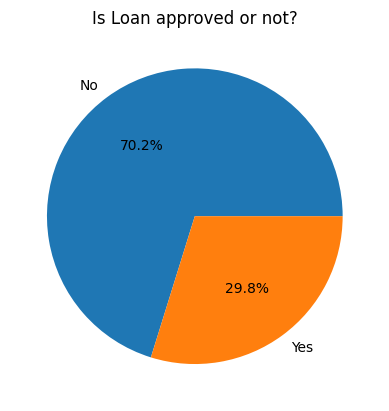

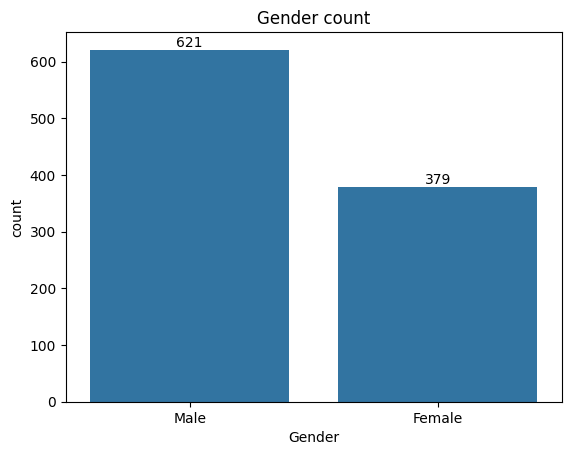

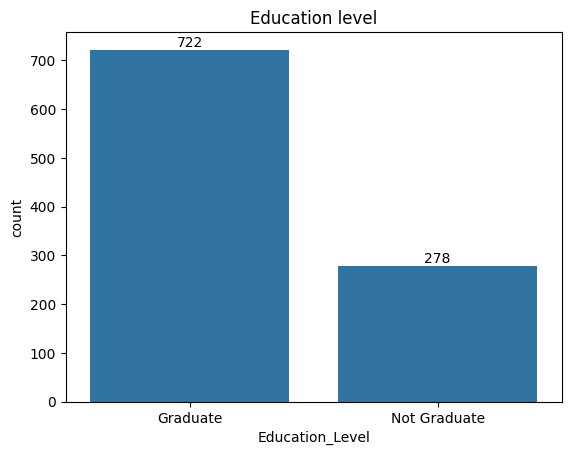

In [544]:
# how balanced our classes are ?

class_count =  df["Loan_Approved"].value_counts()

print(class_count)

plt.pie(class_count, labels=["No","Yes"], autopct="%1.1f%%")        # assign in sequence of value

plt.title("Is Loan approved or not?")
plt.show()





gender_count = df["Gender"].value_counts()
ax=sns.barplot(gender_count)
ax.bar_label(ax.containers[0])
plt.title("Gender count")
plt.show()


Education = df["Education_Level"].value_counts() 
ax=sns.barplot(Education) 
ax.bar_label(ax.containers[0])
plt.title("Education level")
plt.show()


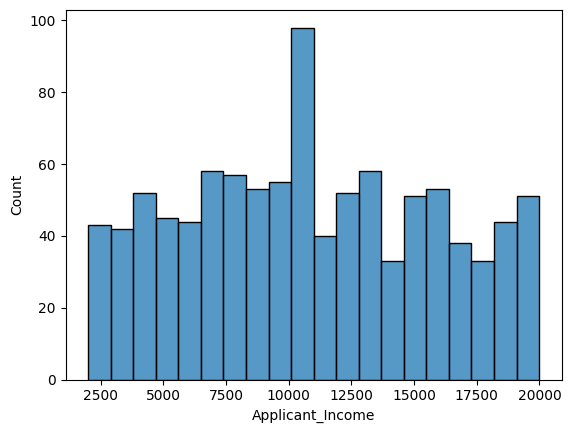

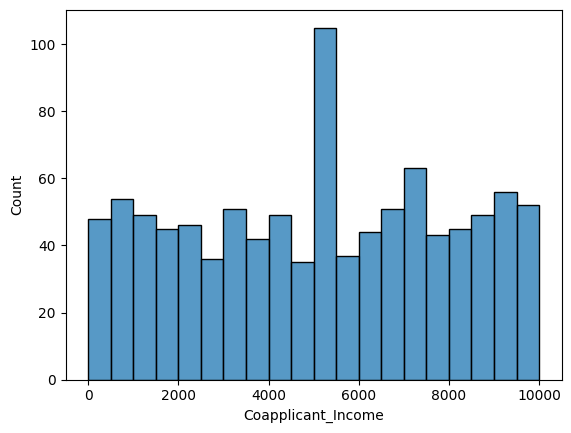

In [545]:
# analyze income

sns.histplot(
    data = df,
    x = "Applicant_Income", 
    bins = 20
)
plt.show()



sns.histplot(
    data = df,
    x = "Coapplicant_Income", 
    bins = 20
)
plt.show()




<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

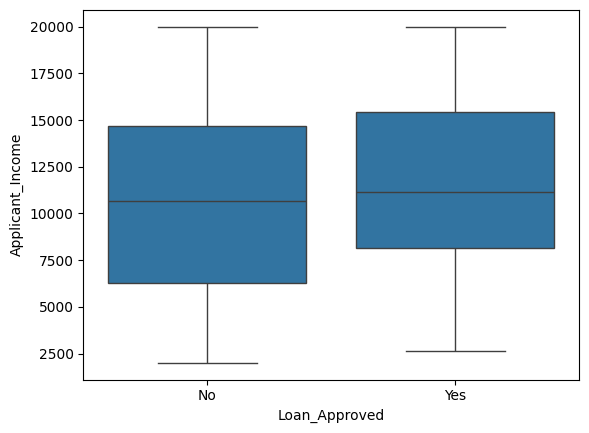

In [546]:
sns.boxplot(
    data=df, 
    x = "Loan_Approved",
    y = "Applicant_Income"
)

# high income has better chance of approval

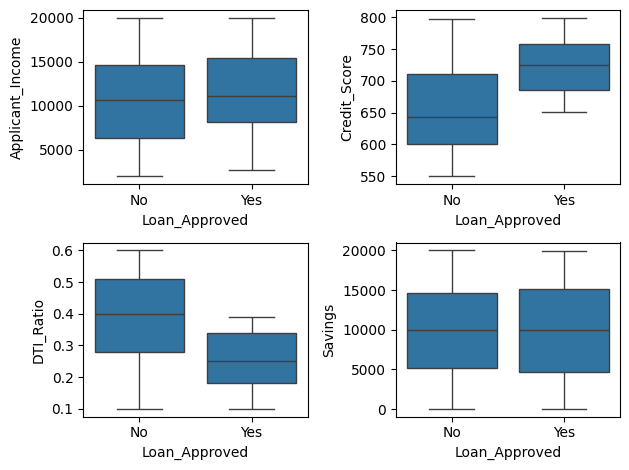

In [547]:
fig, axes = plt. subplots(2, 2)

sns.boxplot(ax=axes[0, 0], data=df, x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes [0, 1], data =df, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1, 0], data =df, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1, 1], data =df, x="Loan_Approved", y="Savings")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

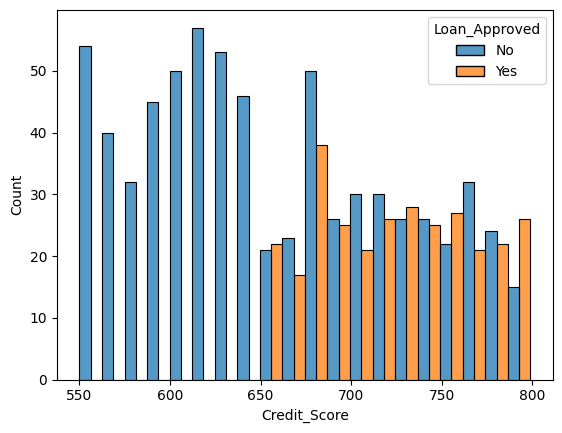

In [548]:
# credit score with loan approvec

sns.histplot(
    data= df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

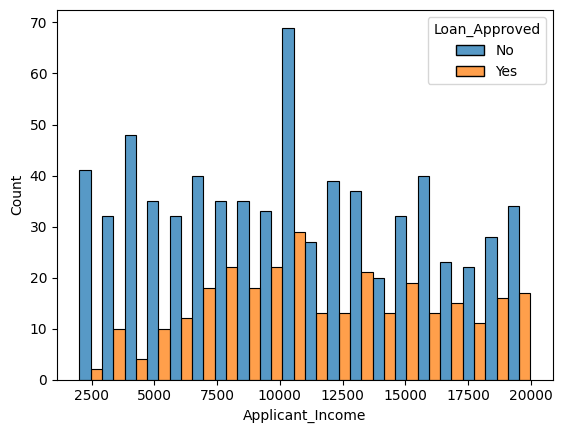

In [549]:
sns.histplot(
    data= df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

### remove Applicant ID

In [550]:
df = df.drop(columns = ["Applicant_ID"])

df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## Step 3 : Encoding

In [551]:
df.info()

# apply label 

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   str    
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   str    
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   str    
 14  Property_Area       1000 non-null   str    
 15  Education_Level     1000 non-null   str    
 16  Gender            

In [552]:
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

le = LabelEncoder()

df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

df.head()



,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [553]:
cols = ["Employment_Status", "Marital_Status" , "Loan_Purpose", "Property_Area" , "Gender" , "Employer_Category"]

ohe = OneHotEncoder(drop = "first" , sparse_output=False , handle_unknown='ignore')

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded , columns=ohe.get_feature_names_out(cols) , index=df.index)



df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)



In [554]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


### Correlation Heatmap

In [555]:
num_cols = df.select_dtypes(include="number")

corr_matrix = num_cols.corr()

In [556]:
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.013108,-0.025975,0.013923,-0.026566


In [557]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

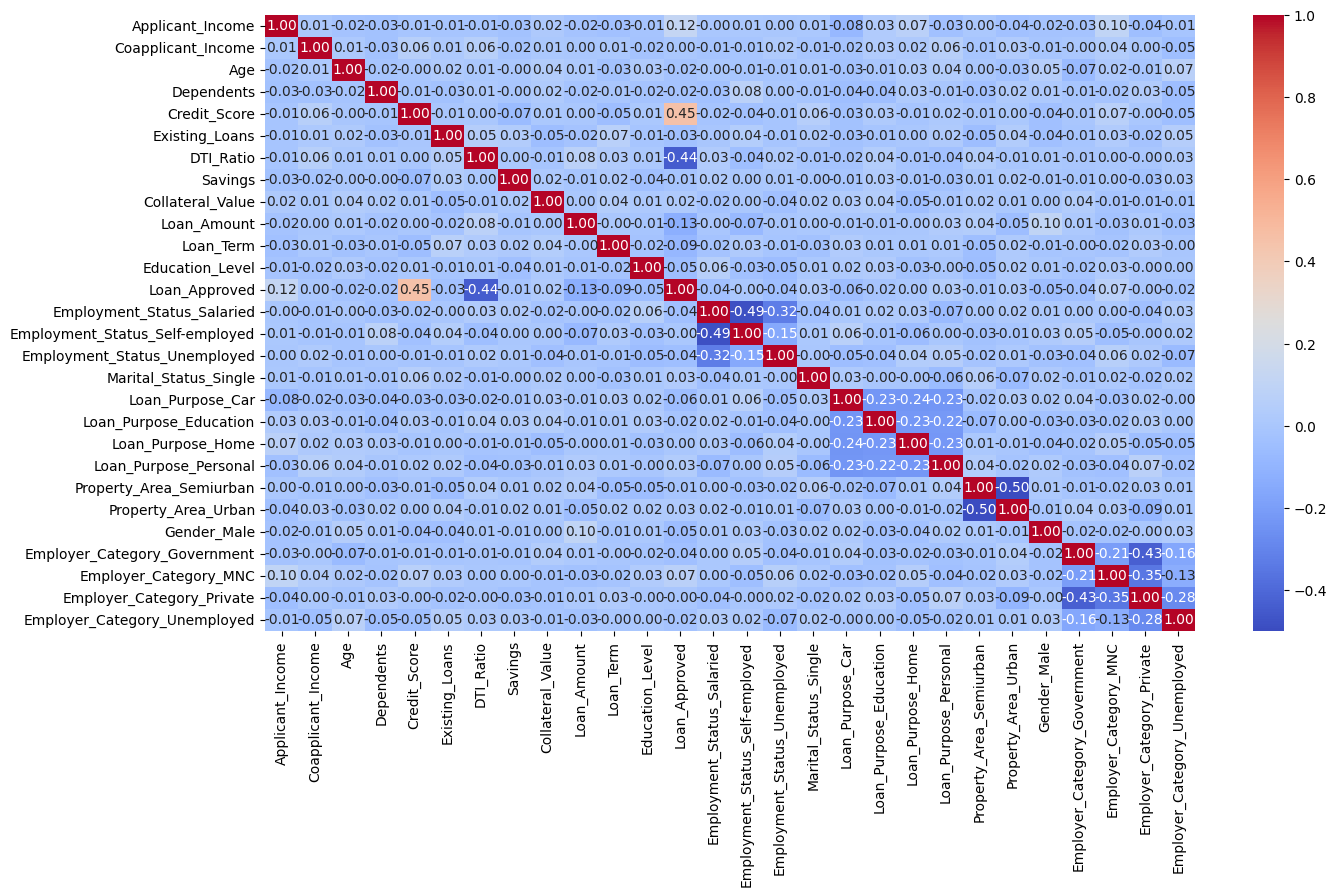

In [558]:
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)


## Step 4 : Training

In [559]:
# Train-test split

X = df.drop(columns=["Loan_Approved"])
y = df["Loan_Approved"]


X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)



In [560]:
# scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)



### Train

### Logistic regression

In [561]:
# train 

# LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score, precision_score, recall_score , f1_score, confusion_matrix

print("LOGISTIC REGRESSION MODEL")
print("Precision : ", precision_score(y_test , y_pred))
print("Recall : ", recall_score(y_test , y_pred))
print("Accuracy : ", accuracy_score(y_test , y_pred))
print("f1 Score : ", f1_score(y_test , y_pred))

print("CM : ", confusion_matrix(y_test , y_pred))

 


LOGISTIC REGRESSION MODEL
Precision :  0.7833333333333333
Recall :  0.7704918032786885
Accuracy :  0.865
f1 Score :  0.7768595041322314
CM :  [[126  13]
 [ 14  47]]


In [562]:
#  evaluate  ---------------------> precision is more important here (according to the problem statement)

### KNN

In [563]:
#KNN

from sklearn.neighbors import KNeighborsClassifier


knn_model = KNeighborsClassifier(n_neighbors=6)

knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

print("KNN MODEL")
print("Precision : ", precision_score(y_test , y_pred))
print("Recall : ", recall_score(y_test , y_pred))
print("Accuracy : ", accuracy_score(y_test , y_pred))
print("f1 Score : ", f1_score(y_test , y_pred))

print("CM : ", confusion_matrix(y_test , y_pred))

KNN MODEL
Precision :  0.6666666666666666
Recall :  0.36065573770491804
Accuracy :  0.75
f1 Score :  0.46808510638297873
CM :  [[128  11]
 [ 39  22]]


### Naive bayes

In [564]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()


nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

print("Naive Bayes MODEL")
print("Precision : ", precision_score(y_test , y_pred))
print("Recall : ", recall_score(y_test , y_pred))
print("Accuracy : ", accuracy_score(y_test , y_pred))
print("f1 Score : ", f1_score(y_test , y_pred))

print("CM : ", confusion_matrix(y_test , y_pred))


Naive Bayes MODEL
Precision :  0.8035714285714286
Recall :  0.7377049180327869
Accuracy :  0.865
f1 Score :  0.7692307692307693
CM :  [[128  11]
 [ 16  45]]


In [565]:
### The best model here out of these are NAIVE BAYES

## Step 5 : Experimentation - Feature engineering

In [566]:
# add or transform features

df["DTI_Ratio_sq"] = df["DTI_Ratio"] **2                                                # increase effect of DTI
df["Credit_Score_sq"] = df["Credit_Score"] **2                                          # increase effect of Credit score


df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])                           # for skewed feature

X = df.drop(columns=["Loan_Approved", "DTI_Ratio", "Credit_Score" , "Applicant_Income", "Applicant_Income"])

y = df["Loan_Approved"]



In [567]:
#split

X = df.drop(columns=["Loan_Approved"])
y = df["Loan_Approved"]


X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)




#scale


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [568]:


# LOGISTIC REGRESSION


log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)


print("LOGISTIC REGRESSION MODEL")
print("Precision : ", precision_score(y_test , y_pred))
print("Recall : ", recall_score(y_test , y_pred))
print("Accuracy : ", accuracy_score(y_test , y_pred))
print("f1 Score : ", f1_score(y_test , y_pred))

print("CM : ", confusion_matrix(y_test , y_pred))


LOGISTIC REGRESSION MODEL
Precision :  0.7903225806451613
Recall :  0.8032786885245902
Accuracy :  0.875
f1 Score :  0.7967479674796748
CM :  [[126  13]
 [ 12  49]]


In [569]:
knn_model = KNeighborsClassifier(n_neighbors=6)

knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

print("KNN MODEL")
print("Precision : ", precision_score(y_test , y_pred))
print("Recall : ", recall_score(y_test , y_pred))
print("Accuracy : ", accuracy_score(y_test , y_pred))
print("f1 Score : ", f1_score(y_test , y_pred))

print("CM : ", confusion_matrix(y_test , y_pred))

KNN MODEL
Precision :  0.813953488372093
Recall :  0.5737704918032787
Accuracy :  0.83
f1 Score :  0.6730769230769231
CM :  [[131   8]
 [ 26  35]]


In [570]:
nb_model = GaussianNB()


nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

print("Naive Bayes MODEL")
print("Precision : ", precision_score(y_test , y_pred))
print("Recall : ", recall_score(y_test , y_pred))
print("Accuracy : ", accuracy_score(y_test , y_pred))
print("f1 Score : ", f1_score(y_test , y_pred))

print("CM : ", confusion_matrix(y_test , y_pred))

Naive Bayes MODEL
Precision :  0.8307692307692308
Recall :  0.8852459016393442
Accuracy :  0.91
f1 Score :  0.8571428571428571
CM :  [[128  11]
 [  7  54]]
